## Entendimiento de la data: EDA con Apache Spark

Se realiza el entendimiento de la data

> Este notebook está escrito como un **informe**: primero se cuenta qué datos tenemos y qué queremos encontrar,
> luego se exploran paso a paso (cada bloque de código va seguido de una breve lectura del resultado) y al final
> se justifica por qué el dataset sirve para **búsqueda por similitud, vecinos más cercanos, streaming y reglas de asociación**.

### 0. Contexto del informe

#### 0.1 Descripción del dataset

Usamos los datos abiertos de **compras públicas del Perú** que publica el OECE en el portal de
[Contrataciones Abiertas](https://contratacionesabiertas.oece.gob.pe/descargas?page=1&paginateBy=10), para los años **2023, 2024 y 2025**.

Los archivos vienen en **JSON** bajo el estándar internacional **OCDS** (*Open Contracting Data Standard*). Cada registro
(*release*) describe un **proceso de contratación** de principio a fin:

- **quién compra** → la entidad pública (`buyer`, `parties`)
- **qué se compra y cómo** → objeto, método, valor referencial, ítems con código UNSPSC (`tender`)
- **a quién se le compró y por cuánto** → proveedor y monto adjudicado (`awards`)

| Característica | Valor (ver salidas de la sección 3.1) |
|---|---|
| Unidad de análisis | 1 fila = 1 proceso de contratación (`ocid`) |
| Volumen | ~3.9 GB de JSON anidado, ~236 mil procesos |
| Periodo | enero 2023 – diciembre 2025 |
| Tipo de datos | texto libre, categorías, montos, fechas y códigos de producto |

#### 0.2 ¿Qué se quiere encontrar?

El objetivo es detectar **señales de riesgo en la compra pública**. Concretamente, tres preguntas guían todo el proyecto:

| # | Pregunta | Por qué importa |
|---|---|---|
| **P1 — Competencia** | ¿Qué combinaciones de método, monto, rubro y región se asocian a procesos con **un solo postor**? | Poca competencia suele traducirse en sobrecostos |
| **P2 — Fraccionamiento** | ¿Hay procesos **casi idénticos** de una misma entidad, en fechas cercanas y con montos bajos? | Puede indicar que se divide una compra para evitar un procedimiento más exigente |
| **P3 — Precios de referencia** | Para procesos con **objeto parecido**, ¿cuánto varía el monto entre entidades y regiones? | Permite encontrar montos atípicos frente a compras similares |

#### 0.3 ¿Por qué este EDA?

Cada análisis del notebook responde a una decisión que tendremos que tomar después, no es exploración "por explorar":

- **Volumen y esquema (3.1):** confirma que el tamaño justifica Spark y que `ocid` sirve como llave única.
- **Nulos (3.2):** decide qué columnas se pueden usar y cuáles se descartan en el KDD.
- **Distribución temporal y por años (3.3, 3.4):** valida que existe un flujo ordenado en el tiempo (**streaming**) y una línea base entre años.
- **Categóricas y montos (3.5, 3.6):** identifica los ítems y tramos que formarán las canastas (**reglas de asociación**).
- **Entidades y proveedores (3.7):** mide repetición y concentración (**Bloom / Count-Min**).
- **Texto y códigos (3.8):** decide sobre qué campo se calcula la **similitud** y los **vecinos**.
- **Multivariado y correlación (3.9, 3.10):** muestra cómo se relacionan las variables y evita usar variables redundantes.
- **Sesgos (3.11):** advierte qué limitaciones hay que tener presentes al interpretar los resultados.

#### 0.4 Contenido

1. Verificación del cluster · 
2. Carga de datos · 
3. Exploración (univariado, multivariado, correlación, sesgos) ·
4. ¿Por qué el dataset es apto? · 
5. Conclusiones ·
6. Cierre de Spark · 

#### Imports

Importa las librerías de Spark, pandas y matplotlib, y configura las opciones de visualización

In [7]:
# Utilidades del sistema y manejo de rutas
import os, socket
from pathlib import Path

# pandas / numpy / matplotlib solo reciben resultados ya agregados por Spark (tablas pequeñas)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Spark: sesión, funciones de columnas y tipos para recorrer el JSON anidado
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.types import ArrayType, StructType

# Gráficos dentro del notebook, con una grilla suave y textos largos visibles
%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80)

#### Utilidades

Calcula las rutas del proyecto, crea la sesión de Spark y define `guardar_fig()` para exportar los gráficos del EDA.

- Constantes

In [8]:
# Si el notebook se abre desde 01_EDA_KDD/, subimos un nivel para encontrar la carpeta data/
proyecto = Path.cwd()
if not (proyecto / "data").exists() and (proyecto.parent / "data").exists():
    proyecto = proyecto.parent

# Carpetas de trabajo: JSON crudos, Parquet intermedio y figuras del EDA
data = proyecto / "data"
parquets = proyecto / "parquet"
figs = proyecto / "outputs" / "eda"
anios = [2023, 2024, 2025]

figs.mkdir(parents=True, exist_ok=True)

# Guarda cada gráfico en outputs/eda/ y además lo muestra en pantalla
def guardar_fig(nombre):
    plt.tight_layout(); plt.savefig(figs / f"{nombre}.png", dpi=120); plt.show()

- Spark

In [9]:
# Si estamos dentro de Docker se usa el cluster (spark://...); si no, Spark local con todos los núcleos
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("eda")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")        # suficiente para ~240 mil filas
           .config("spark.ui.showConsoleProgress", "false")     # evita la barra de progreso en las salidas
           .config("spark.sql.session.timeZone", "America/Lima"))

# En modo cluster, los executors necesitan saber cómo volver a contactar al driver (este notebook)
if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")   # solo mostramos errores, no avisos

### 1. Verificación del cluster

Confirma que el notebook está conectado al cluster de Spark

In [10]:
# Un vistazo rápido a los recursos con los que vamos a trabajar
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master         : {sc.master}")
print(f"Executors      : {estado.size() - 1}")          # se resta 1 porque el driver también aparece en la lista
print(f"Cores totales  : {sc.defaultParallelism}")
print(f"Memoria driver : {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job      : http://localhost:4040")

Master         : spark://spark-master:7077
Executors      : 0
Cores totales  : 2
Memoria driver : 3.0 GB
UI del job      : http://localhost:4040


### 2. Carga de datos

Se carga la data y se guarda una copia plana en Parquet y se trabaja sobre esta

- Auxiliares

In [11]:
# Lee una columna anidada si existe en el esquema; si no, devuelve nulo (así el código no falla entre años)
def col(p, tipo="string"):
    return F.col(p).cast(tipo) if existe(p) else F.lit(None).cast(tipo)

# Las fechas OCDS vienen como texto ISO ("2024-03-15T10:00:00-05:00"); nos quedamos con los 19 primeros caracteres
def fecha(c):
    return F.to_timestamp(F.substring(c.cast("string"), 1, 19), "yyyy-MM-dd'T'HH:mm:ss")

# Recorre el esquema y lista todas las rutas posibles (tender.value.amount, awards.suppliers.name, ...)
def rutas(schema, pre=""):
    out = []
    for f in schema.fields:
        out.append(pre + f.name)
        t = f.dataType.elementType if isinstance(f.dataType, ArrayType) else f.dataType
        if isinstance(t, StructType):
            out += rutas(t, pre + f.name + ".")
    return out

- Lectura de archivos

In [ ]:
# Lista los JSON de cada año en orden natural (1.json, 2.json, ..., 10.json)
def listar_archivos(data, anios):
    archivos = []
    for a in anios:
        archivos += sorted((data / str(a)).glob("*.json"), key=lambda p: (len(p.stem), p.stem))
    return archivos

# Tamaño total en MB de los JSON, para compararlo luego con el Parquet
def resumen_archivos(archivos, data, anios):
    mb_total = sum(a.stat().st_size for a in archivos) / 1024**2
    return mb_total

# Cada archivo es un único JSON grande, por eso se lee con multiLine; PERMISSIVE evita que un registro roto detenga todo
def leer_json(spark, archivos):
    return spark.read.option("multiLine", "true").option("mode", "PERMISSIVE").json([str(a) for a in archivos])

# Los paquetes OCDS pueden venir como "releases" o como "records"; en ambos casos dejamos una fila por proceso
def extraer_releases(raw):
    top = {c.lower() for c in raw.columns}
    if "releases" in top:
        return raw.select(F.explode("releases").alias("r")).select("r.*")
    elif "records" in top:
        rec = raw.select(F.explode("records").alias("x"))
        return (rec.select("x.compiledRelease.*") if "compiledRelease" in rec.select("x.*").columns
                else rec.select(F.explode("x.releases").alias("r")).select("r.*"))
    return raw

- Ejecución de la lectura

In [ ]:
# Ahora sí: leemos todo y dejamos listo el DataFrame de procesos (rel)
archivos = listar_archivos(data, anios)
MB_JSON = resumen_archivos(archivos, data, anios)
raw = leer_json(spark, archivos)
rel = extraer_releases(raw)

# existe("tender.value.amount") -> True/False, sin importar mayúsculas
existe = lambda p: p.lower() in {r.lower() for r in rutas(rel.schema)}

- Vista plana

In [ ]:
# Aplanamos el JSON: pasamos de estructuras anidadas a una tabla simple con las columnas del diccionario de datos
base = rel.select(
    col("ocid").alias("ocid"),
    # Fecha del proceso: inicio de la convocatoria; si falta, la de adjudicación; si falta, la del release
    F.coalesce(fecha(col("tender.tenderPeriod.startDate")),
               fecha(F.element_at(col("awards.date", "array<string>"), 1)),
               fecha(col("date"))).alias("fecha"),
    F.coalesce(col("tender.procuringEntity.name"), col("buyer.name")).alias("entidad"),
    F.input_file_name().alias("_archivo"),
    # Región de la entidad compradora (la parte con rol "buyer")
    (F.expr("element_at(filter(transform(parties, p -> CASE WHEN array_contains(p.roles,'buyer') "
            "THEN p.address.region END), x -> x IS NOT NULL), 1)")
     if existe("parties.address.region") else F.lit(None).cast("string")).alias("region"),
    col("tender.title").alias("codigo_proceso"),
    col("tender.description").alias("descripcion"),
    F.concat_ws(" ", col("tender.items.description", "array<string>")).alias("items_desc"),
    col("tender.status").alias("estado"),
    col("tender.procurementMethod").alias("metodo"),
    col("tender.procurementMethodDetails").alias("metodo_detalle"),
    col("tender.mainProcurementCategory").alias("categoria"),
    col("tender.value.amount", "double").alias("monto_referencial"),
    col("tender.value.currency").alias("moneda"),
    col("tender.numberOfTenderers", "int").alias("n_postores"),
    # Monto adjudicado = suma de todas las adjudicaciones del proceso
    (F.expr("aggregate(filter(awards.value.amount, x -> x IS NOT NULL), CAST(NULL AS DOUBLE), "
            "(acc, x) -> coalesce(acc, 0D) + x)")
     if existe("awards.value.amount") else F.lit(None).cast("double")).alias("monto_adjudicado"),
    # Primer proveedor ganador del proceso
    (F.expr("element_at(filter(transform(awards, a -> element_at(a.suppliers.name, 1)), x -> x IS NOT NULL), 1)")
     if existe("awards.suppliers.name") else F.lit(None).cast("string")).alias("proveedor"),
    # Códigos UNSPSC (sin repetir) de todos los ítems del proceso
    (F.expr("array_distinct(filter(flatten(transform(coalesce(tender.items, array()), "
            "i -> transform(filter(coalesce(i.additionalClassifications, array()), "
            "c -> upper(c.scheme) = 'UNSPSC'), c -> c.id))), x -> x IS NOT NULL))")
     if existe("tender.items.additionalClassifications.id") else F.array().cast("array<string>")).alias("unspsc"))

- Año del proceso y copia en Parquet

In [ ]:
# El año sale de la fecha; si no hay fecha, usamos el nombre de la carpeta (data/2024/...)
base = (base.withColumn("anio_carpeta", F.regexp_extract("_archivo", r"/(\d{4})/[^/]+\.json$", 1).cast("int"))
        .withColumn("anio", F.coalesce(F.year("fecha"), F.col("anio_carpeta"))).drop("_archivo", "anio_carpeta"))

# Guardamos en Parquet y releemos: desde aquí Spark ya no vuelve a parsear el JSON, y todo es mucho más rápido
base.write.mode("overwrite").parquet(str(parquets / "staging"))
base = spark.read.parquet(str(parquets / "staging")).cache()
N = base.count()

### 3. Exploración de los datos

Se explora la data cargada

**Tipos de análisis en esta sección**

| Tipo | Secciones | Qué responde |
|---|---|---|
| Univariado | 3.2, 3.3, 3.5, 3.6, 3.8 | ¿Cómo se distribuye cada variable por separado? |
| Multivariado | 3.4, 3.7, 3.9 | ¿Cómo se comportan las variables cuando las cruzamos? |
| Correlación | 3.10 | ¿Qué variables se mueven juntas (numéricas y categóricas)? |
| Sesgos | 3.11 | ¿Qué limita o distorsiona lo que podemos concluir? |
| Síntesis | 3.12 | ¿El dataset cumple los criterios del proyecto? |

#### 3.1 Volumen y esquema

In [14]:
# ¿Cuántos procesos hay y si algún ocid se repite?
n_ocid = base.select("ocid").distinct().count()
mb_pq = sum(f.stat().st_size for f in (parquets / "staging").rglob("*.parquet")) / 1024**2

print(f"Procesos (filas): {N:,} | ocid únicos: {n_ocid:,} | repetidos: {N - n_ocid:,}")
print(f"Tamaño: JSON {MB_JSON:,.0f} MB  ->  Parquet {mb_pq:,.1f} MB")

# Procesos por año y estructura final de la tabla
base.groupBy("anio").count().orderBy("anio").show()
base.printSchema()

Procesos (filas): 236,229 | ocid únicos: 236,229 | repetidos: 0
Tamaño: JSON 3,860 MB  ->  Parquet 53.0 MB
+----+-----+
|anio|count|
+----+-----+
|2023|76390|
|2024|80263|
|2025|79301|
|2026|  275|
+----+-----+

root
 |-- ocid: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- entidad: string (nullable = true)
 |-- region: string (nullable = true)
 |-- codigo_proceso: string (nullable = true)
 |-- descripcion: string (nullable = true)
 |-- items_desc: string (nullable = true)
 |-- estado: string (nullable = true)
 |-- metodo: string (nullable = true)
 |-- metodo_detalle: string (nullable = true)
 |-- categoria: string (nullable = true)
 |-- monto_referencial: double (nullable = true)
 |-- moneda: string (nullable = true)
 |-- n_postores: integer (nullable = true)
 |-- monto_adjudicado: double (nullable = true)
 |-- proveedor: string (nullable = true)
 |-- unspsc: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- anio: integer (nullable = t

Se tiene alrededor de 4 GB y 240 mil procesos. El costo real estará en parsear JSON anidado y, sobre todo, en las comparaciones por pares en las partes sucesivas, y por ello se pasa  a parquet que reduce el tamaño.

#### 3.1.1 Diccionario de datos

Columnas de la vista plana (`parquet/staging`), de dónde salen en el JSON OCDS y para qué las usaremos.

| Columna | Tipo | Origen OCDS | Descripción | Uso previsto |
|---|---|---|---|---|
| `ocid` | string | `ocid` | Identificador único del proceso | Llave, control de duplicados |
| `fecha` | timestamp | `tender.tenderPeriod.startDate` → `awards.date` → `date` | Fecha del proceso (inicio de convocatoria o la primera disponible) | Orden del flujo (streaming) |
| `anio` | int | derivada de `fecha` o de la carpeta | Año del proceso | Comparar años, particionar |
| `entidad` | string | `tender.procuringEntity.name` / `buyer.name` | Entidad pública que compra | Bloom, Count-Min, filtro de pares LSH |
| `region` | string | `parties[buyer].address.region` | Región de la entidad compradora | Ítem de canasta |
| `codigo_proceso` | string | `tender.title` | Nomenclatura del proceso | Referencia (se descarta en KDD) |
| `descripcion` | string | `tender.description` | Objeto de la contratación en texto libre | Similitud y vecinos |
| `items_desc` | string | `tender.items[].description` | Descripciones de los ítems, concatenadas | Complementa el texto |
| `estado` | string | `tender.status` | Estado del proceso | Vacío → se descarta |
| `metodo` | string | `tender.procurementMethod` | Método según OCDS | Muy incompleto → se descarta |
| `metodo_detalle` | string | `tender.procurementMethodDetails` | Procedimiento según la norma peruana (AS, LP, SIE, etc.) | Ítem de canasta |
| `categoria` | string | `tender.mainProcurementCategory` | Bienes, servicios u obras | Ítem de canasta |
| `monto_referencial` | double | `tender.value.amount` | Valor referencial/estimado | Tramos de monto, comparación de precios |
| `moneda` | string | `tender.value.currency` | Moneda del monto | Filtro (solo PEN) |
| `n_postores` | int | `tender.numberOfTenderers` | Número de postores | Postor único (DGIM, reglas) |
| `monto_adjudicado` | double | Σ `awards[].value.amount` | Monto total adjudicado | Precios de referencia (P3) |
| `proveedor` | string | `awards[0].suppliers[0].name` | Primer proveedor adjudicado | Bloom, Count-Min |
| `unspsc` | array\<string\> | `tender.items[].additionalClassifications` (UNSPSC) | Códigos de producto/servicio | Rubro, ítem de canasta |

#### 3.2 Valores nulos · *univariado*

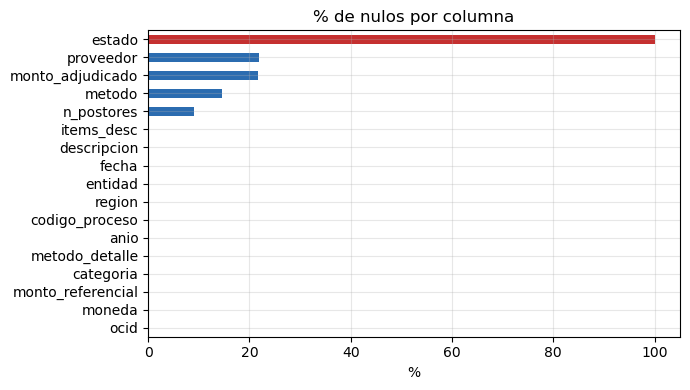

In [15]:
# % de nulos o vacíos por columna (las columnas tipo array se revisan aparte en 3.8)
cols_simples = [c for c, t in base.dtypes if not t.startswith("array")]
nulos = (base.select([(100 * F.count(F.when(F.col(c).isNull() | (F.trim(F.col(c).cast("string")) == ""), 1)) / N)
            .alias(c)for c in cols_simples]).toPandas().T[0].sort_values())

# En rojo las columnas con más de la mitad vacía
nulos.plot.barh(figsize=(7, 4), color=["#c53030" if v > 50 else "#2b6cb0" for v in nulos])
plt.title("% de nulos por columna"); plt.xlabel("%")
guardar_fig("nulos")

Los campos clave (`ocid`, `fecha`, `entidad`, `descripcion`, `monto_referencial`) están completos.
`estado` viene vacío y `metodo` está muy incompleto. Los nulos de `monto_adjudicado`/`proveedor` no son errores: son procesos aún no adjudicados o desiertos.

#### 3.3 Distribución temporal · *univariado*

+-------------------+-------------------+
|                min|                max|
+-------------------+-------------------+
|2023-01-01 00:00:00|2026-09-13 12:05:36|
+-------------------+-------------------+



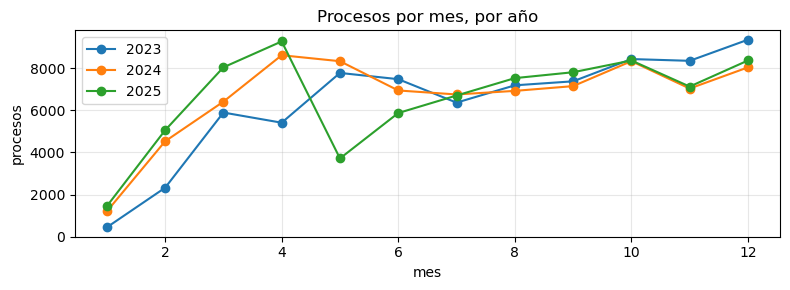

In [16]:
# Rango de fechas del dataset
base.select(F.min("fecha").alias("min"), F.max("fecha").alias("max")).show()

# Procesos por mes, una curva por año, para ver la estacionalidad
serie = (base.where(F.col("anio").isin(anios))
         .groupBy("anio", F.month("fecha").alias("mes")).count()
         .orderBy("anio", "mes").toPandas())

plt.figure(figsize=(8, 3))
for a, g in serie.groupby("anio"):
    plt.plot(g["mes"], g["count"], marker="o", label=a)
plt.title("Procesos por mes, por año"); plt.xlabel("mes"); plt.ylabel("procesos"); plt.legend()
guardar_fig("serie_mensual")

Hay una dimensión temporal continua en los tres años. Las curvas año a año muestran **estacionalidad** (sube hacia fin de año). Dicho flujo largo favorece a los algoritmos de stream.

#### 3.4 Comparación entre años · *multivariado*

In [17]:
# Indicadores clave por año: volumen, actores, monto típico y competencia
por_anio = (base.where(F.col("anio").isin(anios)).groupBy("anio").agg(
        F.count("*").alias("procesos"),
        F.countDistinct("entidad").alias("entidades"),
        F.countDistinct("proveedor").alias("proveedores"),
        F.round(F.expr("percentile_approx(monto_referencial, 0.5)"), 0).alias("monto_mediano"),   # mediana: el monto está muy sesgado
        F.round(100 * F.avg((F.col("n_postores") == 1).cast("int")), 1).alias("%_postor_unico"))
      .orderBy("anio").toPandas())
por_anio

,anio,procesos,entidades,proveedores,monto_mediano,%_postor_unico
0,2023,76390,2633,28804,159656.0,13.6
1,2024,80263,2749,31293,166058.0,11.7
2,2025,79301,2822,31187,185624.0,11.6


Tener tres años permite verificar ciertas cuestiones: si el % de procesos con **un solo postor** sube o baja, si entran proveedores nuevos o se concentran los mismos, y si los montos medianos se mueven. También da una línea base: ver si algún patrón que se repite los tres años es estructural, y no un hecho aislado solo en cierto año.

#### 3.5 Variables categóricas · *univariado*

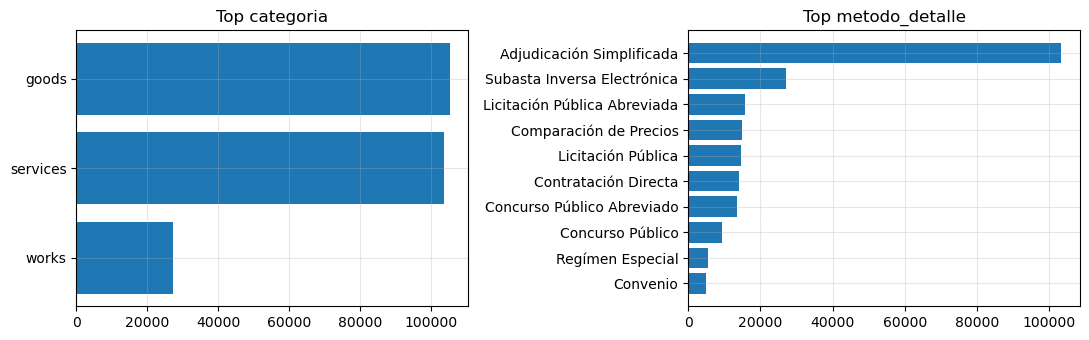

In [18]:
# Top 10 de cada variable categórica (se recorta el texto para que las etiquetas entren)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for i, c in enumerate(["categoria", "metodo_detalle"]):
    d = base.groupBy(c).count().orderBy(F.desc("count")).limit(10).toPandas().iloc[::-1]
    ax[i].barh(d[c].astype(str).str[:35], d["count"]); ax[i].set_title(f"Top {c}")
guardar_fig("categoricas")

Bienes y servicios dominan y obras son menos procesos pero de mayor monto. Pocos métodos como Adjudicación Simplificada, Licitación/Concurso Abreviado, Subasta Inversa concentran la mayoría de procesos.

#### 3.6 Montos · *univariado*

+---------+-------------+
|monto_<=0|moneda_no_PEN|
+---------+-------------+
|    16203|         4797|
+---------+-------------+



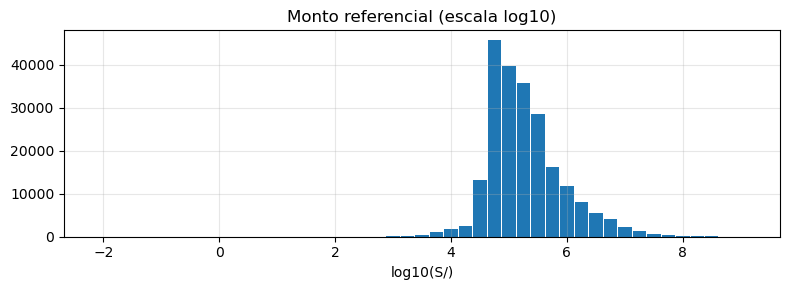

In [19]:
# Cuantiles de los montos positivos
m = base.where(F.col("monto_referencial") > 0)
q = m.approxQuantile("monto_referencial", [.05, .25, .5, .75, .95, .99], 0.01)

# Casos problemáticos que habrá que limpiar en el KDD
base.select(
    F.sum((F.col("monto_referencial") <= 0).cast("int")).alias("monto_<=0"),
    F.sum((F.col("moneda") != "PEN").cast("int")).alias("moneda_no_PEN")).show()

# Histograma en escala logarítmica: en escala normal unos pocos montos enormes aplastan todo el gráfico
hist = (m.groupBy((F.floor(F.log10("monto_referencial") * 4) / 4).alias("log10")).count()
        .orderBy("log10").toPandas())
plt.figure(figsize=(8, 3)); plt.bar(hist["log10"], hist["count"], width=.23)
plt.title("Monto referencial (escala log10)"); plt.xlabel("log10(S/)")
guardar_fig("montos")

Distribución muy sesgada a la derecha. Se discretiza en **tramos de monto** para usarlos como ítems de canasta. Hay montos ≤ 0 y monedas distintas de PEN

#### 3.7 Entidades y proveedores principales · *multivariado*

,n_proveedores,pct_monto_top10
0,66141,5.241068


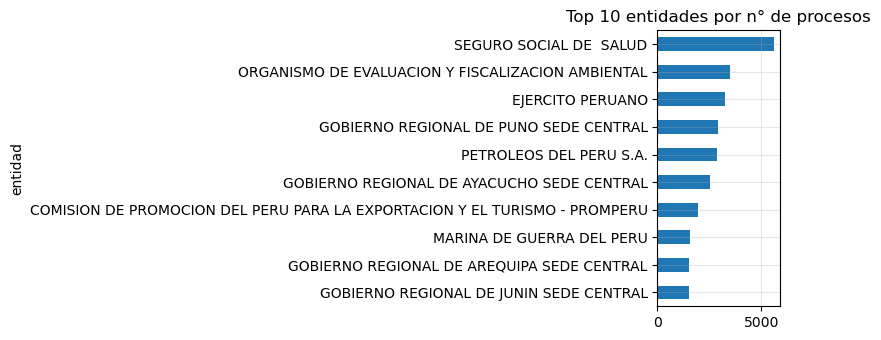

In [20]:
# Registramos la tabla para consultarla con SQL
base.createOrReplaceTempView("procesos")

# Las 10 entidades que más procesos convocan
top_ent = spark.sql('''
    SELECT upper(trim(entidad)) AS entidad, COUNT(*) AS procesos
    FROM procesos GROUP BY 1 ORDER BY procesos DESC LIMIT 10''').toPandas()

# ¿Qué parte del monto adjudicado se llevan los 10 proveedores más grandes?
conc = spark.sql('''
    WITH p AS (SELECT upper(trim(proveedor)) AS proveedor, SUM(monto_adjudicado) AS monto
               FROM procesos WHERE proveedor IS NOT NULL GROUP BY 1)
    SELECT COUNT(*) AS n_proveedores,
           SUM(CASE WHEN rk <= 10 THEN monto END) / SUM(monto) * 100 AS pct_monto_top10
    FROM (SELECT *, ROW_NUMBER() OVER (ORDER BY monto DESC) AS rk FROM p)''').toPandas()
display(conc)

top_ent.iloc[::-1].plot.barh(x="entidad", y="procesos", legend=False, figsize=(8, 3.5))
plt.title("Top 10 entidades por n° de procesos")
guardar_fig("top_entidades")

Hay entidades y proveedores que se repiten mucho y un grupo pequeño de proveedores concentra una parte importante del monto: son candidatos naturales para conteos y para buscar proveedores/procesos parecidos

#### 3.8 Texto y códigos para similitud · *univariado*

In [21]:
# Largo de las descripciones y cantidad de códigos UNSPSC por proceso
txt = base.select(F.size(F.split(F.trim("descripcion"), r"\s+")).alias("palabras"), F.size("unspsc").alias("n_unspsc"))

print("Palabras por descripción (q25, q50, q75, q95):", txt.approxQuantile("palabras", [.25, .5, .75, .95], .01))
print("Descripciones distintas:", base.select("descripcion").distinct().count(), "de", N)
print("Códigos UNSPSC distintos:", base.select(F.explode("unspsc")).distinct().count())

txt.groupBy("n_unspsc").count().orderBy("n_unspsc").show(5)

# Algunas descripciones al azar para ver cómo están escritas
base.select("descripcion").sample(fraction=min(1.0, 50 / N), seed=7).show(5, truncate=90)

Palabras por descripción (q25, q50, q75, q95): [18.0, 29.0, 40.0, 50.0]
Descripciones distintas: 190740 de 236229
Códigos UNSPSC distintos: 5175
+--------+------+
|n_unspsc| count|
+--------+------+
|       0| 36467|
|       1|193160|
|       2|  4666|
|       3|   808|
|       4|   312|
+--------+------+
only showing top 5 rows

+------------------------------------------------------------------------------------------+
|                                                                               descripcion|
+------------------------------------------------------------------------------------------+
|CONTRATACION DE SERVICI ODE CONSULTORIA DE PERITAJE TECNICO Y FINANCIERO DE OBRA DEL PR...|
|SERVICIO DE ARRENDAMIENTO DE INMUEBLES PARA LAS DIFERENTES DIRECCIONES ESPECIALIZADAS P...|
|ADQUISICION DE VESTUARIO PARA EL PERSONAL DE CAMPO QUE LABORA EN EL PLAN DE MANTENIMIEN...|
|Suministro de Bienes: Adquisición de Diesel B5 para la operatividad de las unidades móv...|
|CONTRATACIÓN DEL

`descripcion` siempre existe y tiene decenas de palabras. Buena base para buscar similares. En cambio, la mayoría de procesos tiene **un solo código UNSPSC** o incluso ninguno. Como conjunto es demasiado pobre para similitud por ejemplo con Jaccard. La similitud se hace sobre **texto**, y los códigos se pueden usar como ítems de canasta.

#### 3.9 Análisis multivariado

Hasta aquí vimos cada variable por separado. Ahora las **cruzamos** para ver si la competencia (postor único) y los montos
cambian según la categoría y el método. Si un cruce ya muestra diferencias claras, es una buena pista de que las
**reglas de asociación** (P1) encontrarán patrones con sentido.

In [ ]:
# Nos quedamos con los 6 métodos más usados para que el cruce sea legible
top_metodos = [r["metodo_detalle"] for r in (base.where(F.col("metodo_detalle").isNotNull())
               .groupBy("metodo_detalle").count().orderBy(F.desc("count")).limit(6).collect())]

# % de procesos con un solo postor para cada combinación categoría × método
cruce = (base.where(F.col("metodo_detalle").isin(top_metodos) & F.col("n_postores").isNotNull())
         .groupBy("categoria", "metodo_detalle")
         .agg(F.count("*").alias("procesos"),
              F.round(100 * F.avg((F.col("n_postores") == 1).cast("int")), 1).alias("pct_postor_unico"))
         .toPandas())
tabla = cruce.pivot(index="categoria", columns="metodo_detalle", values="pct_postor_unico")

# Mapa de calor: más oscuro = menos competencia
fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(tabla.values, cmap="Reds", aspect="auto")
ax.set_xticks(range(tabla.shape[1]), [str(c)[:22] for c in tabla.columns], rotation=30, ha="right")
ax.set_yticks(range(tabla.shape[0]), tabla.index.astype(str))
for i in range(tabla.shape[0]):
    for j in range(tabla.shape[1]):
        v = tabla.values[i, j]
        if not np.isnan(v):
            ax.text(j, i, f"{v:.0f}%", ha="center", va="center", fontsize=8)
ax.grid(False); fig.colorbar(im, ax=ax, label="% postor único")
plt.title("% de procesos con un solo postor: categoría × método")
guardar_fig("multivariado_postor_unico")

**Cómo leerlo:** cada celda es el porcentaje de procesos con un solo postor para esa combinación. Las celdas más oscuras
son las combinaciones con menor competencia; justamente las que esperamos ver como consecuente `{postor único}` en las reglas.
Si los colores fueran parejos, el método y la categoría no explicarían la competencia y habría que apoyarse más en monto o región.

In [ ]:
# Muestra acotada (~30 mil procesos) para graficar en pandas sin saturar el driver
muestra = (base.where(F.col("monto_referencial") > 0)
           .select("categoria",
                   F.log10("monto_referencial").alias("log_ref"),
                   F.log10(F.when(F.col("monto_adjudicado") > 0, F.col("monto_adjudicado"))).alias("log_adj"))
           .sample(fraction=min(1.0, 30000 / N), seed=7).toPandas())

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Izquierda: distribución del monto (log) por categoría
grupos = [g["log_ref"].values for _, g in muestra.groupby("categoria")]
ax[0].boxplot(grupos, showfliers=False)
ax[0].set_xticks(range(1, len(grupos) + 1), [str(c) for c in muestra.groupby("categoria").groups])
ax[0].set_title("Monto referencial por categoría"); ax[0].set_ylabel("log10(S/)")

# Derecha: referencial vs adjudicado; los puntos sobre la diagonal se adjudicaron casi al valor referencial
par = muestra.dropna(subset=["log_adj"])
for c, g in par.groupby("categoria"):
    ax[1].scatter(g["log_ref"], g["log_adj"], s=3, alpha=.3, label=c)
lim = [par[["log_ref", "log_adj"]].min().min(), par[["log_ref", "log_adj"]].max().max()]
ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set_title("Referencial vs adjudicado"); ax[1].set_xlabel("log10 referencial"); ax[1].set_ylabel("log10 adjudicado")
ax[1].legend(markerscale=4)
guardar_fig("multivariado_montos")

**Cómo leerlo:** a la izquierda se compara el monto típico de bienes, servicios y obras (se espera que obras esté más arriba).
A la derecha, si la nube sigue la diagonal, el monto adjudicado se parece al referencial; los puntos muy alejados son candidatos
a **precios atípicos**, que es lo que buscaremos comparando cada proceso con sus **vecinos más cercanos** (P3).

#### 3.10 Correlación

Medimos qué tan relacionadas están las variables de dos formas:

- **Numéricas → Spearman:** usa rangos en vez de valores, así que no se deja arrastrar por los montos extremos (que ya vimos que son muy sesgados).
- **Categóricas → V de Cramér:** va de 0 (sin relación) a 1 (una variable determina a la otra). Nos dice si dos ítems de la canasta aportan información distinta o repiten lo mismo.

In [ ]:
# Variables numéricas sobre una muestra de ~50 mil procesos (suficiente para estimar correlaciones)
num = (base.where(F.col("monto_referencial") > 0)
       .select(F.log10("monto_referencial").alias("log_monto_ref"),
               F.log10(F.when(F.col("monto_adjudicado") > 0, F.col("monto_adjudicado"))).alias("log_monto_adj"),
               F.col("n_postores").cast("double").alias("n_postores"),
               (F.col("n_postores") == 1).cast("double").alias("postor_unico"),
               F.size(F.split(F.trim("descripcion"), r"\s+")).cast("double").alias("palabras_desc"),
               F.size("unspsc").cast("double").alias("n_unspsc"),
               F.month("fecha").cast("double").alias("mes"))
       .sample(fraction=min(1.0, 50000 / N), seed=7).toPandas())

corr = num.corr(method="spearman")

fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=40, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.grid(False); fig.colorbar(im, ax=ax)
plt.title("Correlación de Spearman (variables numéricas)")
guardar_fig("correlacion_numericas")

In [ ]:
# V de Cramér calculada a mano con numpy (no depende de scipy)
def cramer_v(a, b):
    t = pd.crosstab(a, b).values.astype(float)
    if min(t.shape) < 2:
        return np.nan
    n = t.sum()
    esperado = t.sum(1, keepdims=True) @ t.sum(0, keepdims=True) / n
    chi2 = ((t - esperado) ** 2 / esperado).sum()
    return np.sqrt(chi2 / (n * (min(t.shape) - 1)))

# Mismas variables que irán a la canasta del KDD (tramo de monto aproximado por cuartiles)
cat = (base.select("categoria", "metodo_detalle", "region", "monto_referencial",
                   (F.col("n_postores") == 1).cast("string").alias("postor_unico"))
       .sample(fraction=min(1.0, 50000 / N), seed=7).toPandas())
cat["tramo_monto"] = pd.qcut(cat["monto_referencial"].where(cat["monto_referencial"] > 0), 4,
                             labels=["bajo", "medio", "alto", "muy alto"])
cat = cat.drop(columns="monto_referencial")

vars_cat = list(cat.columns)
cramer = pd.DataFrame([[cramer_v(cat[a], cat[b]) for b in vars_cat] for a in vars_cat],
                      index=vars_cat, columns=vars_cat).round(2)
cramer

- En Spearman, valores cercanos a ±1 indican variables que se mueven juntas. Se espera una relación fuerte entre monto referencial y adjudicado (uno se deriva del otro) y cierta relación entre monto y número de postores. Las variables muy correlacionadas **no deben usarse juntas** como si fueran información independiente.
- En Cramér, un valor alto entre dos ítems (p. ej. `metodo_detalle` y `tramo_monto`, porque la ley asigna el método según el monto) significa que las reglas los mostrarán siempre juntos: son reglas **obvias**, no hallazgos. Lo interesante es la relación de cada ítem con `postor_unico`.

#### 3.11 Sesgos asociados

Ningún dataset es neutral. Antes de minar conviene saber **qué parte de la realidad no vemos** o vemos distorsionada,
para no confundir un artefacto de los datos con un hallazgo. Primero los cuantificamos:

In [ ]:
# Indicadores simples de cada sesgo (todos en %)
sesgos = base.select(
    F.round(100 * F.avg(F.col("n_postores").isNull().cast("int")), 1).alias("sin_n_postores"),
    F.round(100 * F.avg(F.col("proveedor").isNull().cast("int")), 1).alias("sin_proveedor"),
    F.round(100 * F.avg(F.upper("region").contains("LIMA").cast("int")), 1).alias("region_lima"),   # sobre los que tienen región
    F.round(100 * F.avg((~F.col("anio").isin(anios)).cast("int")), 2).alias("fuera_de_rango"),
    F.round(100 * (1 - F.countDistinct("descripcion") / F.count("*")), 1).alias("desc_repetidas")
).toPandas()

sesgos["top10_entidades"] = round(100 * top_ent["procesos"].sum() / N, 1)   # reutiliza el top de 3.7
sesgos.T.rename(columns={0: "%"})

| Sesgo | Qué pasa en los datos | Efecto en el análisis | Cómo lo manejamos |
|---|---|---|---|
| **Selección / cobertura** | Solo aparece lo que se publica como procedimiento en OCDS; las compras menores exceptuadas no están | Los resultados describen procesos formales, no todo el gasto público | Se aclara el alcance en las conclusiones |
| **Datos faltantes no aleatorios** | `proveedor`, `monto_adjudicado` y `n_postores` faltan sobre todo en procesos desiertos o en curso | Si solo analizamos adjudicados, vemos sobre todo procesos "exitosos" | Se conservan los procesos sin adjudicar para texto y frecuencias (KDD) |
| **Truncamiento temporal** | Los procesos de fines de 2025 aún pueden no estar adjudicados; hay fechas en 2026 | El % de postor único y los montos del último tramo pueden estar subestimados | Filtrar 2023–2025 y comparar con cuidado el último trimestre |
| **Concentración / popularidad** | Pocas entidades generan muchos procesos | Count-Min y las reglas con soporte mínimo reflejan sobre todo a los grandes | Revisar reglas con *lift* y no solo soporte; comparar dentro de cada entidad |
| **Geográfico** | Gran parte de las entidades está en Lima | Las reglas por región pueden estar dominadas por Lima | Leer las reglas regionales con su soporte propio |
| **Texto plantilla** | Muchas descripciones se repiten o siguen formatos estándar, con erratas | Similitud alta sin que sea fraccionamiento; o baja por errores de tipeo | Shingles de caracteres (toleran erratas) + filtro por misma entidad y fechas cercanas |
| **Moneda y montos inválidos** | Hay montos ≤ 0 y monedas distintas de PEN | Distorsiona tramos y comparación de precios | Solo PEN y montos ≤ 0 como nulos (KDD) |
| **Muestreo del propio EDA** | Algunas figuras usan muestras y cuantiles aproximados | Pequeñas variaciones en los números | Semilla fija (`seed=7`) y conteos exactos donde importa |

#### 3.12 Análisis general del dataset

In [22]:
# Resumen: cada criterio del enunciado con la evidencia que encontramos arriba
en_rango = base.where(F.col("anio").isin(anios)).count()
dictamen = pd.DataFrame([
    ("Volumen para Spark",        f"{MB_JSON:,.0f} MB JSON, {N:,} procesos ({len(anios)} años), {N * (N - 1) / 2 / 1e6:,.0f} millones de pares posibles", "Sí"),
    ("Conjuntos / vectores",      f"descripción completa ({100 - nulos['descripcion']:.0f}%) -> shingles / TF-IDF", "Sí"),
    ("Dimensión temporal",        f"{100 * en_rango / N:.1f}% de procesos con fecha en {min(anios)}-{max(anios)}", "Sí"),
    ("Estructura transaccional",  "categoría, método, región, tramo de monto, competencia, rubro UNSPSC", "Sí"),
], columns=["criterio del enunciado", "evidencia del EDA", "cumple"])
dictamen

,criterio del enunciado,evidencia del EDA,cumple
0,Volumen para Spark,"3,860 MB JSON, 236,229 procesos (3 años), 27,902 millones de pares posibles",Sí
1,Conjuntos / vectores,descripción completa (100%) -> shingles / TF-IDF,Sí
2,Dimensión temporal,99.9% de procesos con fecha en 2023-2025,Sí
3,Estructura transaccional,"categoría, método, región, tramo de monto, competencia, rubro UNSPSC",Sí


- Jaccard/MinHash/LSH → `descripcion` (texto libre, comparable por shingles)

- TF-IDF/ANN → `descripcion`, `monto_referencial` (vectoriza texto, compara montos parecidos)

- Bloom/Count-Min → `entidad`, `proveedor` (detectan repetición y reincidencia)

- DGIM → `fecha`, `n_postores` (ordenan el flujo y marcan postor único)

- Apriori/FP-Growth → `categoria`, `metodo_detalle`, `region`, `monto_referencial` (son los ítems categóricos de la canasta)

### 4. El por qué de nuestro Dataset :D

#### 4.1 Búsqueda por similitud (Jaccard, MinHash, LSH)

- **Idea:** cada descripción se convierte en un **conjunto de shingles** (trozos de *k* caracteres) y se compara con Jaccard. Comparar todos los pares es inviable (~27 900 millones), así que **MinHash** resume cada conjunto en una firma corta y **LSH** agrupa en *buckets* solo los pares con alta probabilidad de ser parecidos.
- **Por qué:** `descripcion` está presente en prácticamente todos los procesos, tiene ~30 palabras en mediana y cerca de una de cada cinco se repite: hay casi-duplicados reales que encontrar. El volumen hace que LSH sea necesario, no opcional.
- **Buscamos:** pares de procesos casi idénticos **de la misma entidad y en fechas cercanas** → posible fraccionamiento (**P2**).

#### 4.2 Vecinos más cercanos (TF-IDF + ANN: IVF / HNSW)

- **Idea:** cada proceso se representa como un **vector TF-IDF** (las palabras raras pesan más que las comunes) y se buscan los *k* vectores más cercanos por coseno. La búsqueda exacta recorre todo el dataset por consulta; los métodos **aproximados** lo evitan: **IVF** divide el espacio en grupos y solo revisa los más cercanos, y **HNSW** navega un grafo jerárquico de "atajos" entre vecinos.
- **Por qué:** el texto tiene un vocabulario rico y cada proceso trae un **monto** con el cual comparar a sus vecinos.
- **Buscamos:** para cada proceso, sus *k* procesos más parecidos y la dispersión de sus montos → **precios atípicos** frente a compras similares (**P3**).

#### 4.3 Streaming (Bloom Filter, Count-Min Sketch, DGIM)

- **Idea:** los datos se procesan **como un flujo**, en orden de llegada y con memoria pequeña y fija, sin guardar todo el historial.
  - **Bloom Filter:** responde "¿ya vi este elemento?" sin falsos negativos (puede tener algunos falsos positivos).
  - **Count-Min Sketch:** estima frecuencias (nunca subestima) y permite hallar los elementos más frecuentes (*heavy hitters*).
  - **DGIM:** cuenta cuántos "1" hubo en los últimos *N* elementos del flujo usando memoria $O(\log^2 N)$.
- **Por qué:** casi todos los procesos tienen fecha dentro de 2023–2025, llegan de forma continua (con estacionalidad) y hay entidades y proveedores que se repiten mucho.
- **Buscamos:** pares entidad–proveedor que **reinciden** (Bloom), proveedores y entidades **dominantes** (Count-Min) y la **tasa reciente de postor único** en una ventana deslizante (DGIM) (**P1, P2**).

#### 4.4 Reglas de asociación (Apriori, FP-Growth)

- **Idea:** cada proceso es una **canasta de ítems** (`método=AS`, `tramo=bajo`, `región=CUSCO`, `postor_unico=1`...). Se buscan reglas $X \Rightarrow Y$ evaluadas con **soporte** (qué tan frecuente es), **confianza** (qué tan seguido se cumple) y **lift** (si la relación es mayor que la esperada por azar; lift > 1). **Apriori** poda candidatos usando que todo subconjunto de un conjunto frecuente es frecuente; **FP-Growth** comprime las canastas en un árbol y evita generar candidatos.
- **Por qué:** hay variables categóricas de baja cardinalidad (categoría, método, región, tramo de monto, rubro) y un consecuente claro (`postor único`), sobre más de 200 mil transacciones.
- **Buscamos:** reglas del tipo `{método, tramo de monto, región} ⇒ {postor único}` con lift > 1 → **perfiles de baja competencia** (**P1**).

#### 4.5 Resumen

| Técnica | Requisito teórico | Evidencia en el EDA | Pregunta |
|---|---|---|---|
| Similitud (Jaccard / MinHash / LSH) | Objetos representables como conjuntos, muchos pares | `descripcion` completa, descripciones repetidas, miles de millones de pares | P2 |
| Vecinos (TF-IDF / IVF / HNSW) | Objetos representables como vectores + variable a comparar | Texto rico + `monto_referencial` / `monto_adjudicado` | P3 |
| Streaming (Bloom / Count-Min / DGIM) | Datos ordenados en el tiempo y elementos repetidos | `fecha` continua con estacionalidad, `entidad` / `proveedor` repetidos, `n_postores` | P1, P2 |
| Reglas (Apriori / FP-Growth) | Transacciones con ítems categóricos | categoría, método, región, tramo, rubro, postor único | P1 |

### 5. Conclusiones

- El dataset es **grande, continuo en el tiempo y rico en texto y categorías**, así que cumple los requisitos de las cuatro familias de técnicas.
- La similitud y los vecinos se trabajarán sobre el **texto** de la descripción; los códigos UNSPSC son muy pobres como conjunto y se usarán como **rubro** dentro de la canasta.
- Se descartan `estado` y `metodo` (casi vacíos), se filtra a **PEN** y los montos ≤ 0 pasan a nulo: estas decisiones se aplican en `b_kdd.ipynb`.
- Los resultados deben leerse con los **sesgos** de la sección 3.11 en mente: cobertura, datos faltantes no aleatorios, truncamiento del último periodo y concentración en pocas entidades y en Lima.

### 6. Cerrar sesión de Spark

Libera los recursos del cluster cerrando la SparkSession.

In [23]:
# Liberamos memoria y executors del cluster
spark.stop()